In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install py7zr pillow opencv-python imagehash pandas matplotlib tqdm scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 492.7/492.7 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 15.3 MB/s eta 0:00:00


In [3]:
import re
import cv2
import py7zr
import hashlib
import imagehash
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from tqdm import tqdm

In [4]:
DATA_DIR = Path("/content/drive/MyDrive/Underwater-Image-Data-set-main")

archives = list(DATA_DIR.glob("*.7z"))

print("Archives found:")

for archive in archives:
    print(archive.name)

print("\nTotal archives:", len(archives))

Archives found:
epoch_00100.7z
epoch_0096.7z
epoch_0135.7z
epoch_100.7z
epoch_0110.7z
epoch_0115.7z
epoch_0100.7z
epoch_0120.7z

Total archives: 8


In [5]:
EXTRACT_DIR = Path("/content/extracted_dataset")

EXTRACT_DIR.mkdir(exist_ok=True)

for archive in archives:

    archive_folder = EXTRACT_DIR / archive.stem
    archive_folder.mkdir(exist_ok=True)

    print(f"Extracting {archive.name}...")

    with py7zr.SevenZipFile(archive, mode="r") as z:
        z.extractall(path=archive_folder)

print("\nAll archives extracted!")

Extracting epoch_00100.7z...
Extracting epoch_0096.7z...
Extracting epoch_0135.7z...
Extracting epoch_100.7z...
Extracting epoch_0110.7z...
Extracting epoch_0115.7z...
Extracting epoch_0100.7z...
Extracting epoch_0120.7z...

All archives extracted!


In [6]:
IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg"
}

image_files = [
    p for p in EXTRACT_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total images:", len(image_files))

print("\nExamples:")

for img in image_files[:10]:
    print(img)

Total images: 3694

Examples:
/content/extracted_dataset/epoch_0135/epoch_0135/img 33_gen.png
/content/extracted_dataset/epoch_0135/epoch_0135/img 69_input.png
/content/extracted_dataset/epoch_0135/epoch_0135/img 33_input.png
/content/extracted_dataset/epoch_0135/epoch_0135/img 9_target.png
/content/extracted_dataset/epoch_0135/epoch_0135/img 42_target.png
/content/extracted_dataset/epoch_0135/epoch_0135/img 99_target.png
/content/extracted_dataset/epoch_0135/epoch_0135/img 91_target.png
/content/extracted_dataset/epoch_0135/epoch_0135/img 51_input.png
/content/extracted_dataset/epoch_0135/epoch_0135/img 97_input.png
/content/extracted_dataset/epoch_0135/epoch_0135/img 23_gen.png


In [7]:
pattern = re.compile(
    r"img_(\d+)_(input|target|gen)",
    re.IGNORECASE
)

records = []

for path in image_files:

    match = pattern.fullmatch(path.stem)

    if match:

        image_id = match.group(1)
        category = match.group(2).lower()

        # First folder after extracted_dataset
        source_archive = path.relative_to(
            EXTRACT_DIR
        ).parts[0]

        records.append({
            "file": str(path),
            "filename": path.name,
            "source_archive": source_archive,
            "image_id": image_id,
            "category": category
        })

df = pd.DataFrame(records)

print(df.head())

print("\nCategory counts:")

print(df["category"].value_counts())

                                                file           filename  \
0  /content/extracted_dataset/epoch_0096/epoch_00...  img_118_input.png   
1  /content/extracted_dataset/epoch_0096/epoch_00...     img_47_gen.png   
2  /content/extracted_dataset/epoch_0096/epoch_00...  img_124_input.png   
3  /content/extracted_dataset/epoch_0096/epoch_00...  img_152_input.png   
4  /content/extracted_dataset/epoch_0096/epoch_00...  img_71_target.png   

  source_archive image_id category  
0     epoch_0096      118    input  
1     epoch_0096       47      gen  
2     epoch_0096      124    input  
3     epoch_0096      152    input  
4     epoch_0096       71   target  

Category counts:
category
input     157
gen       157
target    157
Name: count, dtype: int64


In [8]:
EXPECTED = {"input", "target", "gen"}

triplet_results = []

for (archive, image_id), group in df.groupby(
    ["source_archive", "image_id"]
):

    categories_found = set(group["category"])

    triplet_results.append({

        "source_archive": archive,
        "image_id": image_id,

        "categories_found": ", ".join(
            sorted(categories_found)
        ),

        "complete_triplet":
            categories_found == EXPECTED,

        "missing_categories": ", ".join(
            sorted(EXPECTED - categories_found)
        )
    })

triplet_df = pd.DataFrame(triplet_results)

print("Total samples:", len(triplet_df))

print(
    "Complete triplets:",
    triplet_df["complete_triplet"].sum()
)

print(
    "Incomplete triplets:",
    (~triplet_df["complete_triplet"]).sum()
)

Total samples: 157
Complete triplets: 157
Incomplete triplets: 0


In [9]:
incomplete_triplets = triplet_df[
    ~triplet_df["complete_triplet"]
]

incomplete_triplets

,source_archive,image_id,categories_found,complete_triplet,missing_categories


In [10]:
incomplete_triplets.to_csv(
    "/content/incomplete_triplets.csv",
    index=False
)

In [11]:
corrupt_images = []
valid_images = []

for path in tqdm(image_files):

    try:

        with Image.open(path) as img:
            img.verify()

        valid_images.append(path)

    except Exception as e:

        corrupt_images.append({
            "file": str(path),
            "error": str(e)
        })

print("Valid images:", len(valid_images))
print("Corrupt images:", len(corrupt_images))

100%|██████████| 3694/3694 [00:00<00:00, 4467.44it/s]

Valid images: 3694
Corrupt images: 0


In [12]:
corrupt_df = pd.DataFrame(corrupt_images)

corrupt_df.to_csv(
    "/content/corrupt_images.csv",
    index=False
)

In [13]:
image_info = []

for path in tqdm(valid_images):

    try:

        with Image.open(path) as img:

            width, height = img.size

            image_info.append({

                "file": str(path),

                "width": width,
                "height": height,

                "resolution":
                    f"{width}x{height}",

                "format": img.format,
                "mode": img.mode,

                "channels":
                    len(img.getbands())
            })

    except Exception:
        pass


image_info_df = pd.DataFrame(image_info)

100%|██████████| 3694/3694 [00:00<00:00, 24292.62it/s]


In [14]:
image_info_df = image_info_df.merge(

    df[
        [
            "file",
            "source_archive",
            "image_id",
            "category"
        ]
    ],

    on="file",

    how="left"
)

image_info_df.head()

,file,width,height,resolution,format,mode,channels,source_archive,image_id,category
0,/content/extracted_dataset/epoch_0135/epoch_01...,256,256,256x256,PNG,RGB,3,NaN,NaN,NaN
1,/content/extracted_dataset/epoch_0135/epoch_01...,256,256,256x256,PNG,RGB,3,NaN,NaN,NaN
2,/content/extracted_dataset/epoch_0135/epoch_01...,256,256,256x256,PNG,RGB,3,NaN,NaN,NaN
3,/content/extracted_dataset/epoch_0135/epoch_01...,256,256,256x256,PNG,RGB,3,NaN,NaN,NaN
4,/content/extracted_dataset/epoch_0135/epoch_01...,256,256,256x256,PNG,RGB,3,NaN,NaN,NaN


In [15]:
resolution_counts = (

    image_info_df["resolution"]
    .value_counts()
)

resolution_counts.head(20)

,count
resolution,
256x256,3694


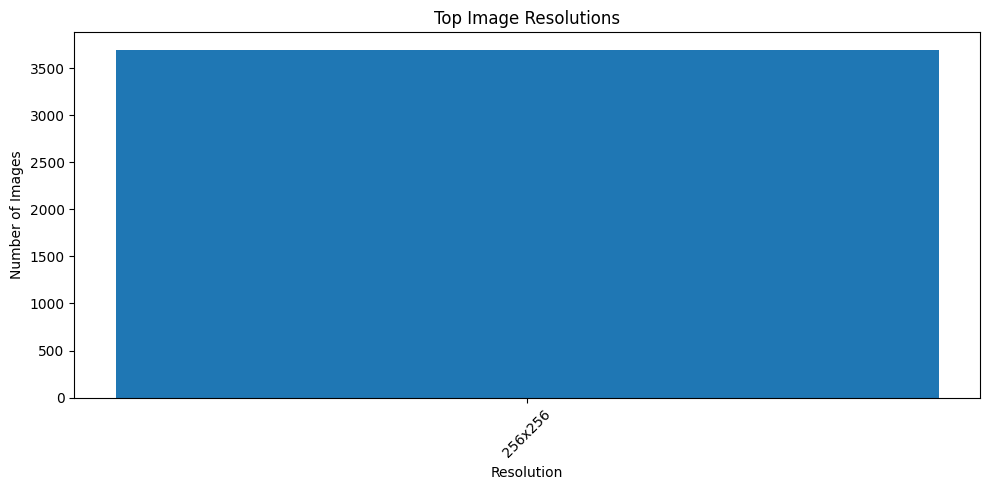

In [16]:
top_resolutions = resolution_counts.head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_resolutions.index,
    top_resolutions.values
)

plt.xticks(rotation=45)

plt.xlabel("Resolution")
plt.ylabel("Number of Images")

plt.title(
    "Top Image Resolutions"
)

plt.tight_layout()

plt.savefig(
    "/content/resolution_distribution.png",
    dpi=300
)

plt.show()

In [17]:
resolution_problems = []

for (archive, image_id), group in image_info_df.groupby(

    ["source_archive", "image_id"]

):

    # Only check complete triplets

    if len(group) != 3:
        continue

    resolutions = set(

        zip(
            group["width"],
            group["height"]
        )

    )

    if len(resolutions) > 1:

        resolution_problems.append({

            "source_archive": archive,

            "image_id": image_id,

            "resolutions": str(
                list(resolutions)
            )
        })


resolution_problems_df = pd.DataFrame(
    resolution_problems
)

print(
    "Triplets with inconsistent resolution:",
    len(resolution_problems_df)
)

Triplets with inconsistent resolution: 0


In [18]:
resolution_problems_df.to_csv(
    "/content/resolution_problems.csv",
    index=False
)

In [19]:
quality_data = []

for path in tqdm(valid_images):

    img = cv2.imread(str(path))

    if img is None:
        continue

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    brightness = gray.mean()

    contrast = gray.std()

    sharpness = cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()


    quality_data.append({

        "file": str(path),

        "brightness": brightness,

        "contrast": contrast,

        "sharpness": sharpness

    })


quality_df = pd.DataFrame(
    quality_data
)

100%|██████████| 3694/3694 [00:10<00:00, 343.84it/s]


In [20]:
quality_df = quality_df.merge(

    df[
        [
            "file",
            "source_archive",
            "image_id",
            "category"
        ]
    ],

    on="file",

    how="left"
)

In [21]:
quality_summary = (

    quality_df
    .groupby("category")[
        [
            "brightness",
            "contrast",
            "sharpness"
        ]
    ]
    .agg(
        ["mean", "median", "std"]
    )
)

quality_summary

brightness                          contrast                        \
                mean      median        std       mean     median        std   
category                                                                       
gen       152.100787  152.325897  63.874775  42.619983  45.515397  18.299541   
input     157.052753  143.953339  37.089814  13.492417  11.276946   7.953359   
target    153.152862  148.288132  64.579074  45.068073  48.607562  18.930606   

           sharpness                          
                mean      median         std  
category                                      
gen       295.255281  304.174519  179.622378  
input      27.353461    8.880672   31.093901  
target    517.099037  436.123840  512.679765

<Figure size 800x500 with 0 Axes>

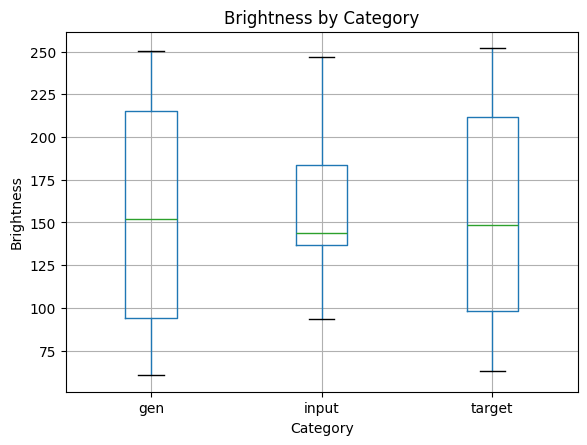

In [22]:
plt.figure(figsize=(8, 5))

quality_df.boxplot(
    column="brightness",
    by="category"
)

plt.title(
    "Brightness by Category"
)

plt.suptitle("")

plt.xlabel("Category")
plt.ylabel("Brightness")

plt.savefig(
    "/content/brightness_comparison.png",
    dpi=300
)

plt.show()

<Figure size 800x500 with 0 Axes>

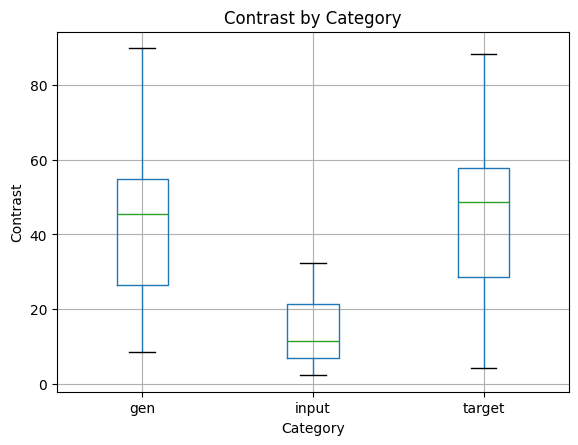

In [23]:
plt.figure(figsize=(8, 5))

quality_df.boxplot(
    column="contrast",
    by="category"
)

plt.title(
    "Contrast by Category"
)

plt.suptitle("")

plt.xlabel("Category")
plt.ylabel("Contrast")

plt.savefig(
    "/content/contrast_comparison.png",
    dpi=300
)

plt.show()

<Figure size 800x500 with 0 Axes>

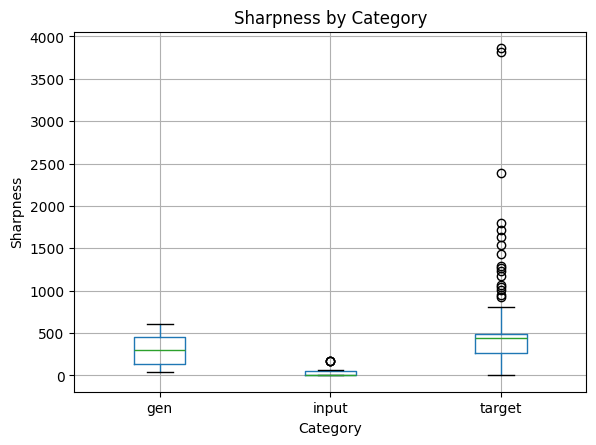

In [24]:
plt.figure(figsize=(8, 5))

quality_df.boxplot(
    column="sharpness",
    by="category"
)

plt.title(
    "Sharpness by Category"
)

plt.suptitle("")

plt.xlabel("Category")
plt.ylabel("Sharpness")

plt.savefig(
    "/content/sharpness_comparison.png",
    dpi=300
)

plt.show()

In [25]:
def get_md5(path):

    md5 = hashlib.md5()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(8192),
            b""
        ):
            md5.update(chunk)

    return md5.hexdigest()

In [27]:
import hashlib
import pandas as pd
from tqdm import tqdm

# Function to create an MD5 hash for each image
def get_md5(path):
    md5 = hashlib.md5()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            md5.update(chunk)

    return md5.hexdigest()


# Create hashes for all valid images
hash_records = []

for path in tqdm(valid_images):
    try:
        hash_records.append({
            "file": str(path),
            "md5": get_md5(path)
        })

    except Exception as e:
        print(f"Error processing {path}: {e}")


# Convert results to a DataFrame
hash_df = pd.DataFrame(hash_records)


# Find exact duplicates
duplicates_df = hash_df[
    hash_df.duplicated(
        subset="md5",
        keep=False
    )
].sort_values("md5")


# Display results
print("Total images checked:", len(hash_df))
print("Files involved in exact duplicates:", len(duplicates_df))

display(duplicates_df.head(20))


# Save results as a CSV
duplicates_df.to_csv(
    "/content/exact_duplicates.csv",
    index=False
)

print("\nFile saved at:")
print("/content/exact_duplicates.csv")

100%|██████████| 3694/3694 [00:00<00:00, 4839.30it/s]

Total images checked: 3694
Files involved in exact duplicates: 2591


,file,md5
1153,/content/extracted_dataset/epoch_100/epoch_100...,000e189b13e99a7da3c52da20832535d
1060,/content/extracted_dataset/epoch_100/epoch_100...,000e189b13e99a7da3c52da20832535d
1357,/content/extracted_dataset/epoch_100/epoch_100...,000e189b13e99a7da3c52da20832535d
1074,/content/extracted_dataset/epoch_100/epoch_100...,000e189b13e99a7da3c52da20832535d
2121,/content/extracted_dataset/epoch_0110/epoch_01...,003be8b5463168a4cf4040957f402c35
3510,/content/extracted_dataset/epoch_0100/epoch_01...,003be8b5463168a4cf4040957f402c35
2192,/content/extracted_dataset/epoch_0110/epoch_01...,003be8b5463168a4cf4040957f402c35
3122,/content/extracted_dataset/epoch_0115/epoch_01...,003be8b5463168a4cf4040957f402c35
3214,/content/extracted_dataset/epoch_0115/epoch_01...,003be8b5463168a4cf4040957f402c35
2284,/content/extracted_dataset/epoch_0110/epoch_01...,003be8b5463168a4cf4040957f402c35



File saved at:
/content/exact_duplicates.csv


In [28]:
duplicates_df.to_csv(
    "/content/exact_duplicates.csv",
    index=False
)

In [29]:
quality_df[
    [
        "brightness",
        "contrast",
        "sharpness"
    ]
].describe()

,brightness,contrast,sharpness
count,3694.000000,3694.000000,3694.000000
mean,112.313127,42.985465,370.583129
std,45.361724,16.469721,504.114043
min,1.029419,2.190974,0.836532
25%,102.664093,30.544542,149.420074
50%,123.574112,46.075530,218.426906
75%,133.786987,55.377579,321.624659
max,252.079788,89.997166,3863.142431


In [30]:
dark_images = quality_df[
    quality_df["brightness"] < 30
]

blurry_images = quality_df[
    quality_df["sharpness"] < 50
]

print(
    "Potentially very dark images:",
    len(dark_images)
)

print(
    "Potentially blurry images:",
    len(blurry_images)
)

Potentially very dark images: 315
Potentially blurry images: 306


In [31]:
dark_images.to_csv(
    "/content/dark_images.csv",
    index=False
)

blurry_images.to_csv(
    "/content/blurry_images.csv",
    index=False
)

In [32]:
complete_samples = triplet_df[
    triplet_df["complete_triplet"]
]

sample = complete_samples.sample(
    n=min(10, len(complete_samples)),
    random_state=42
)

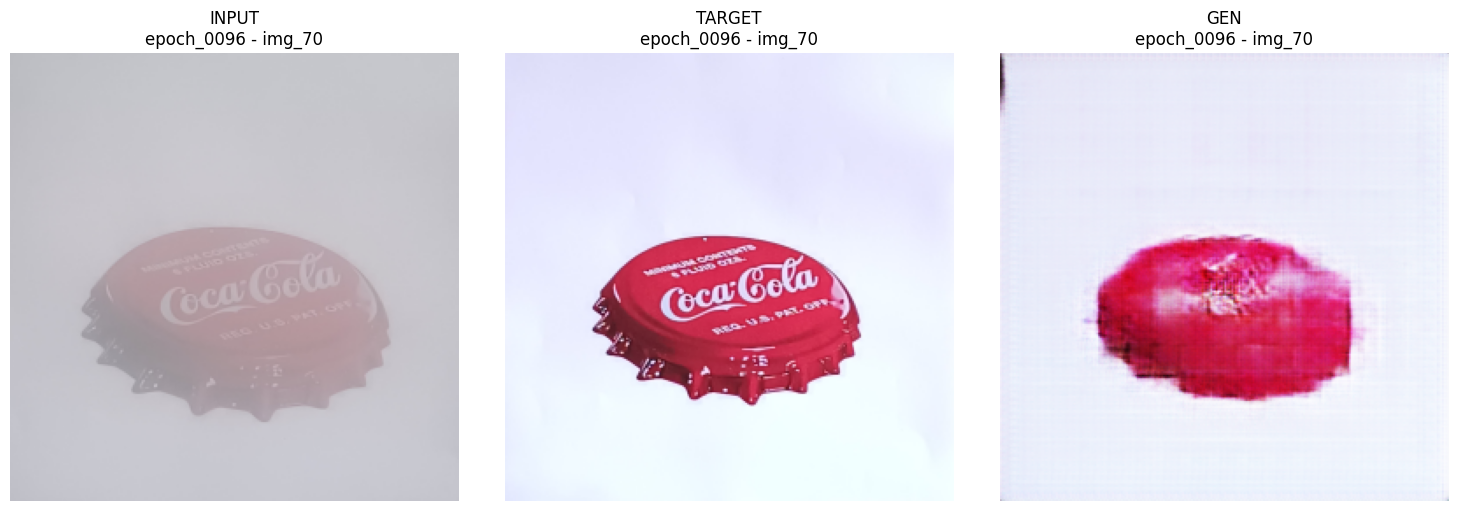

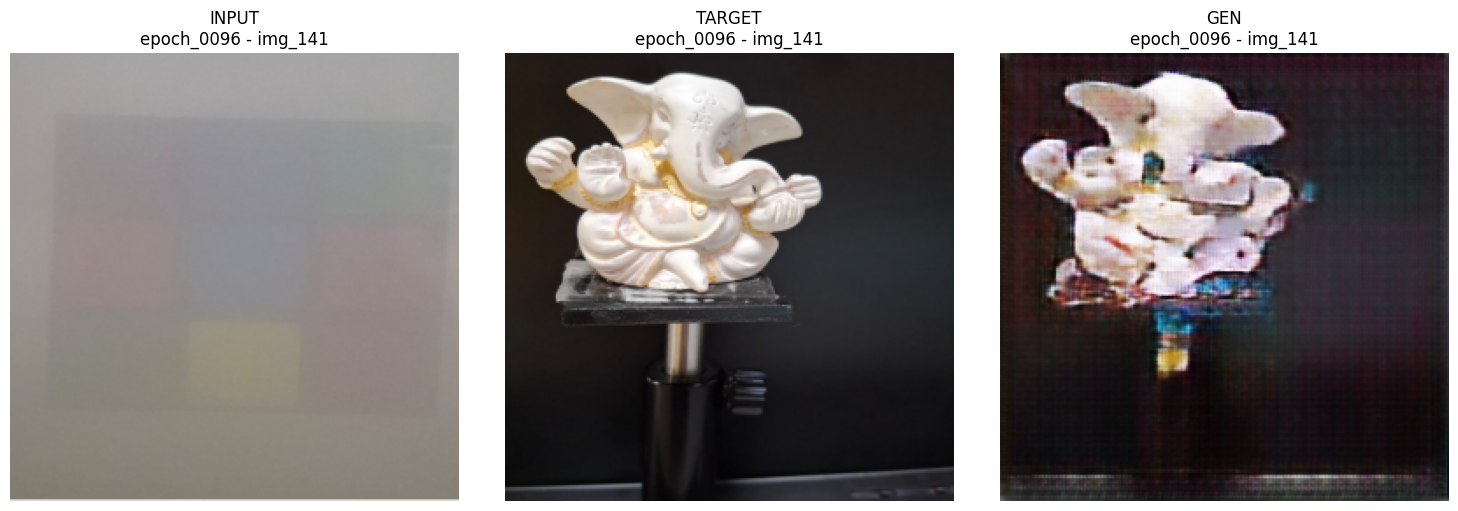

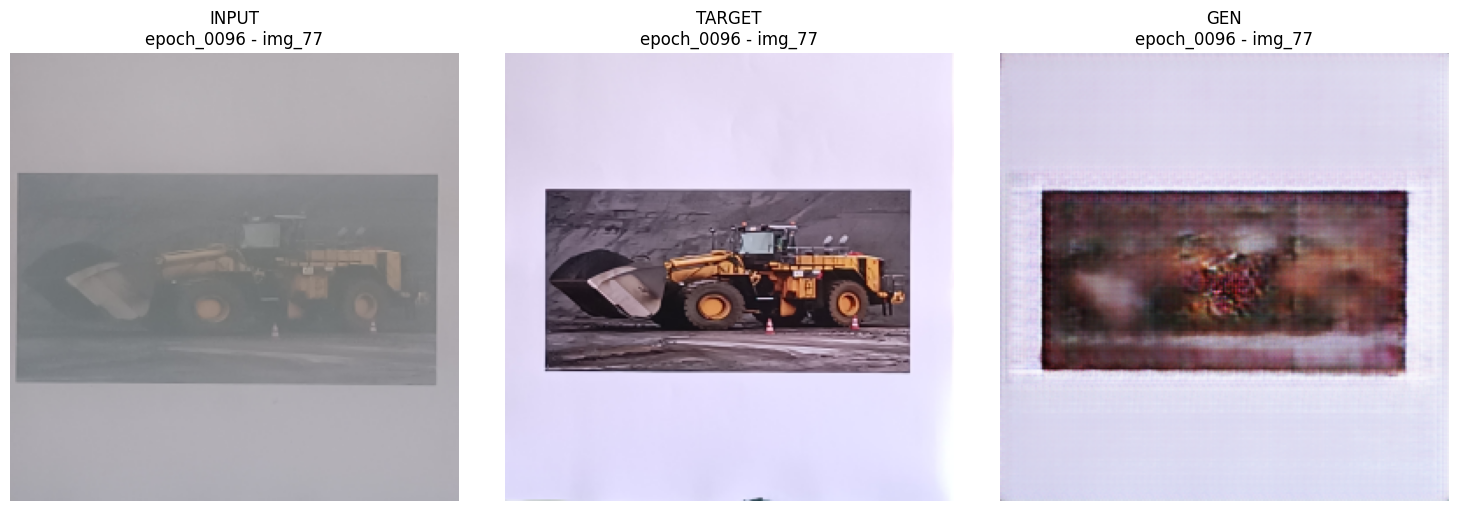

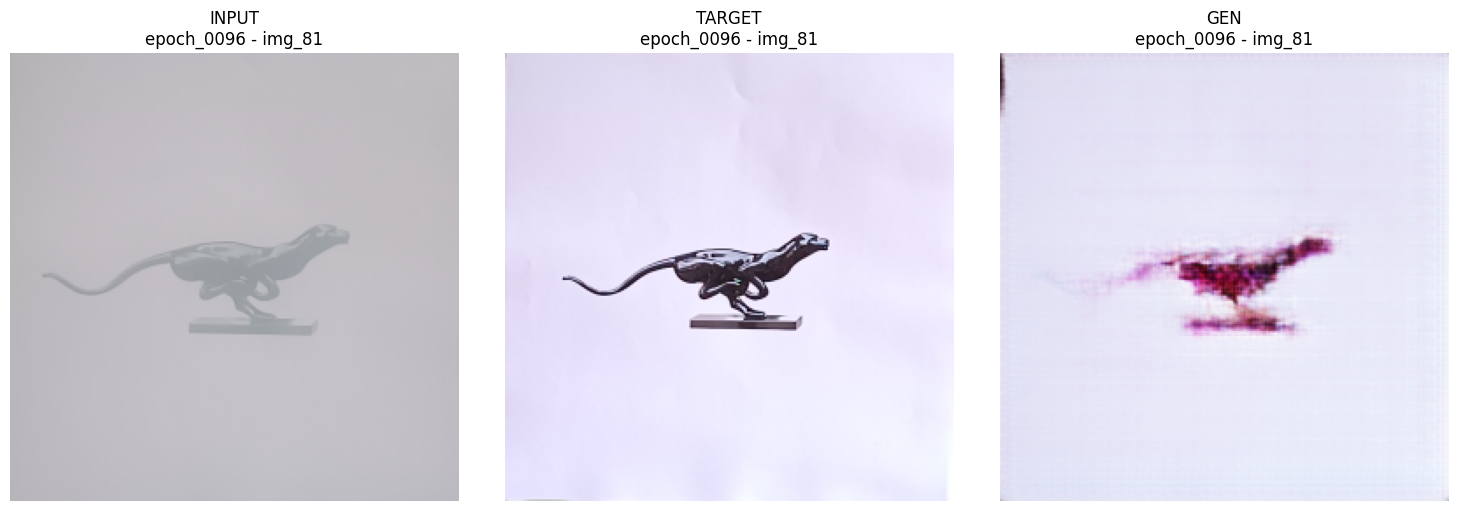

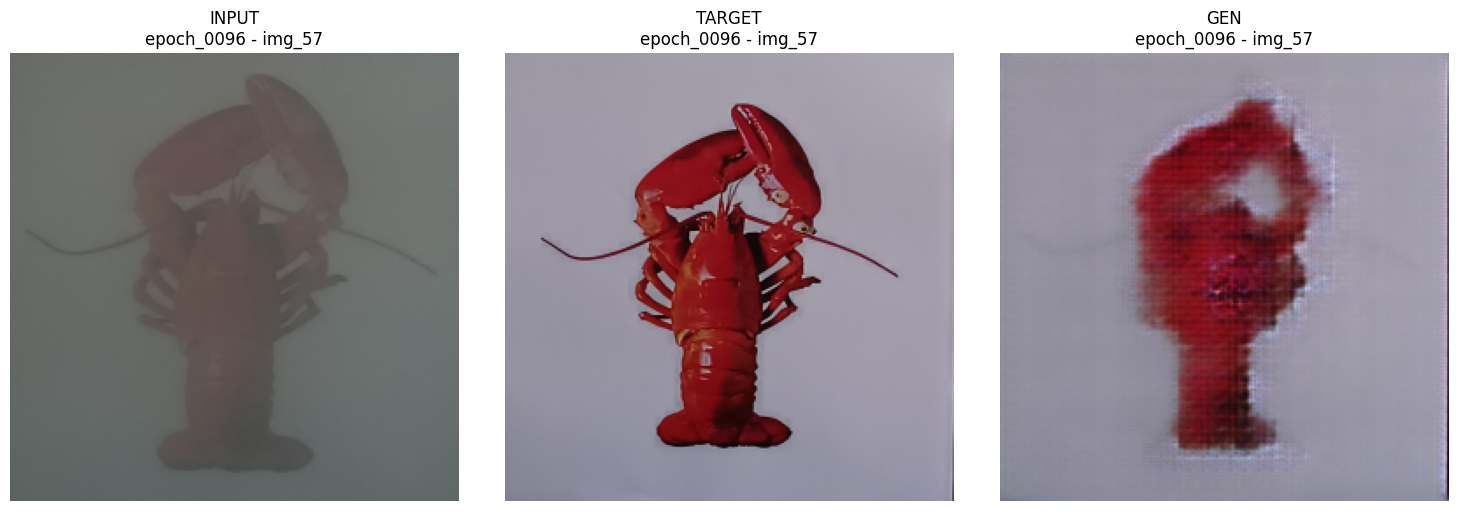

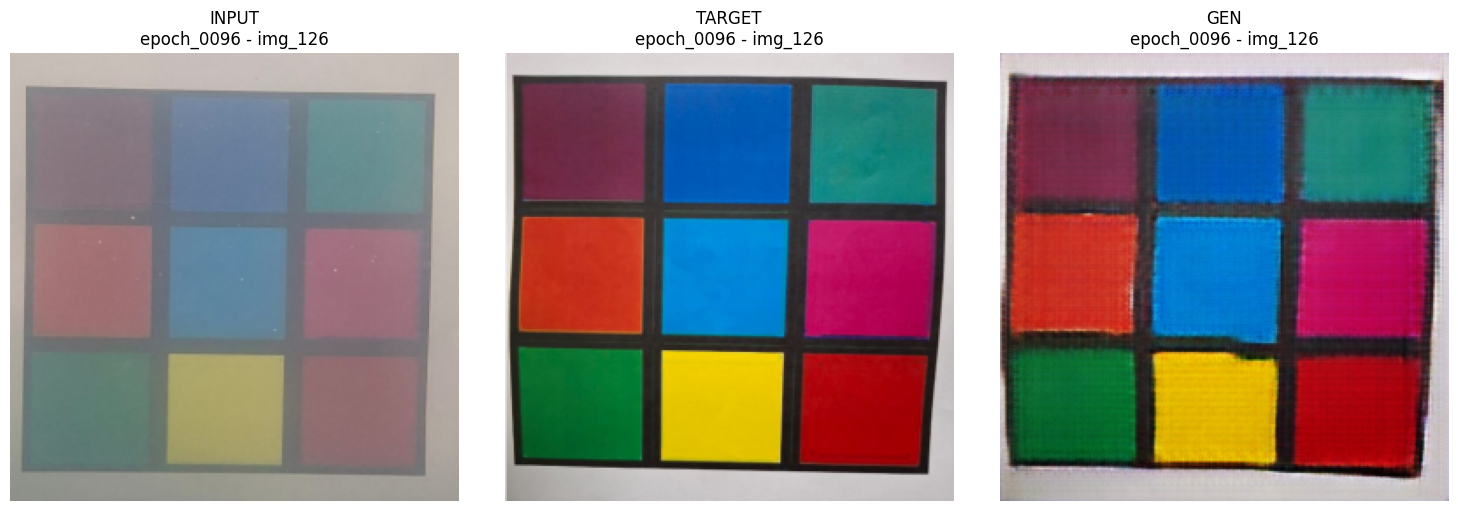

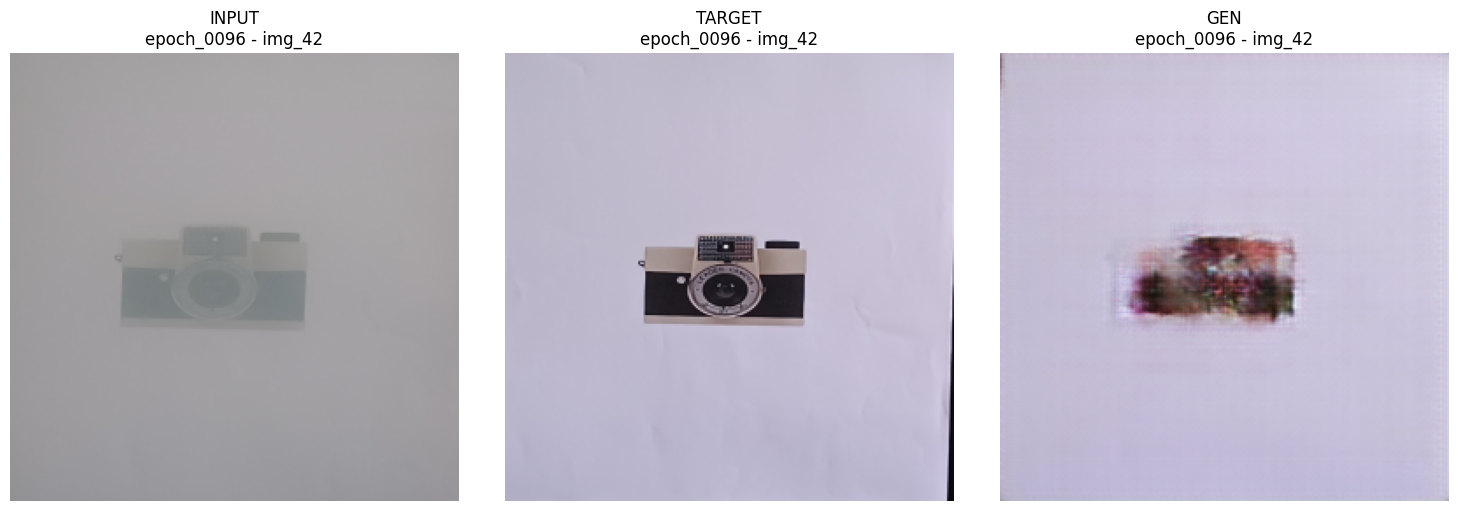

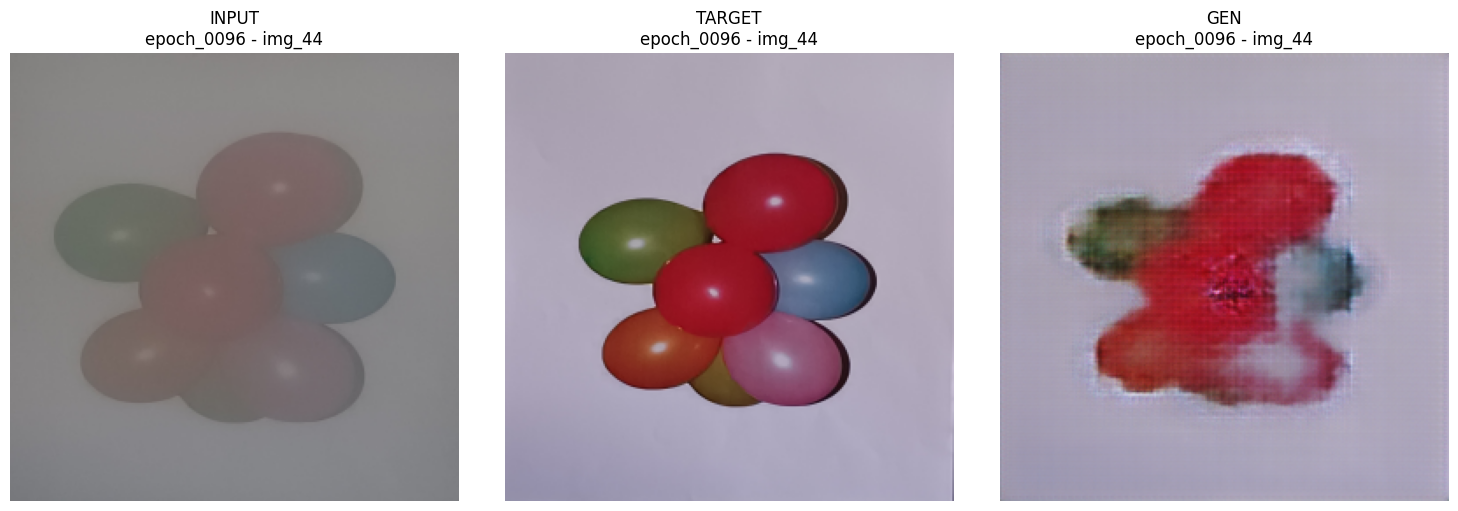

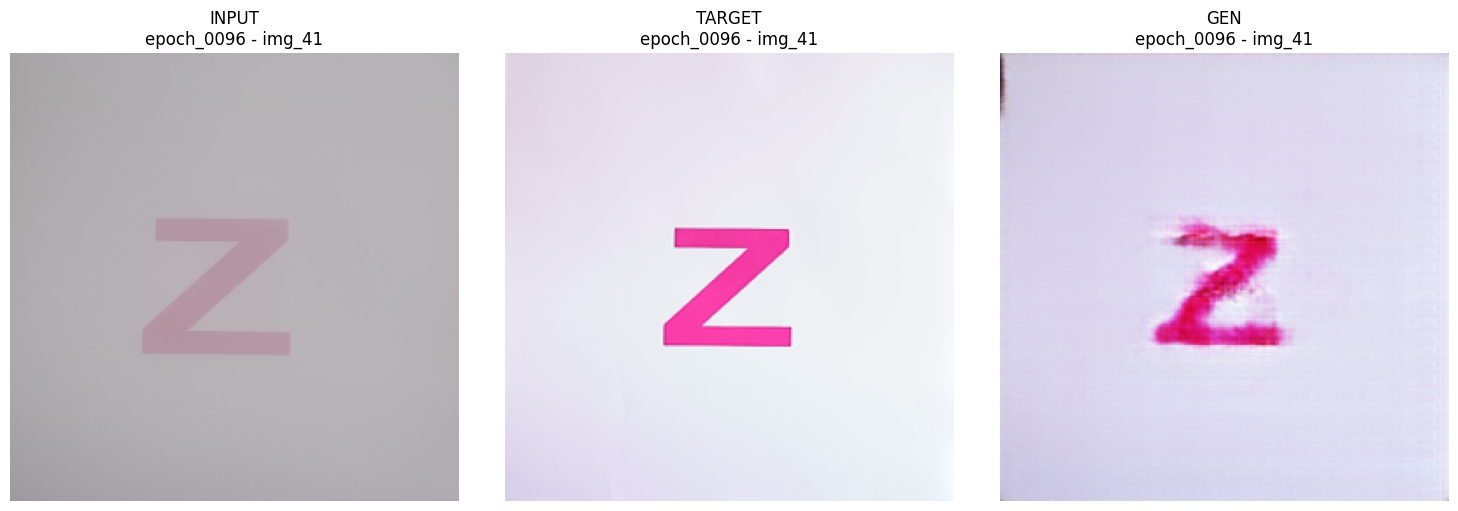

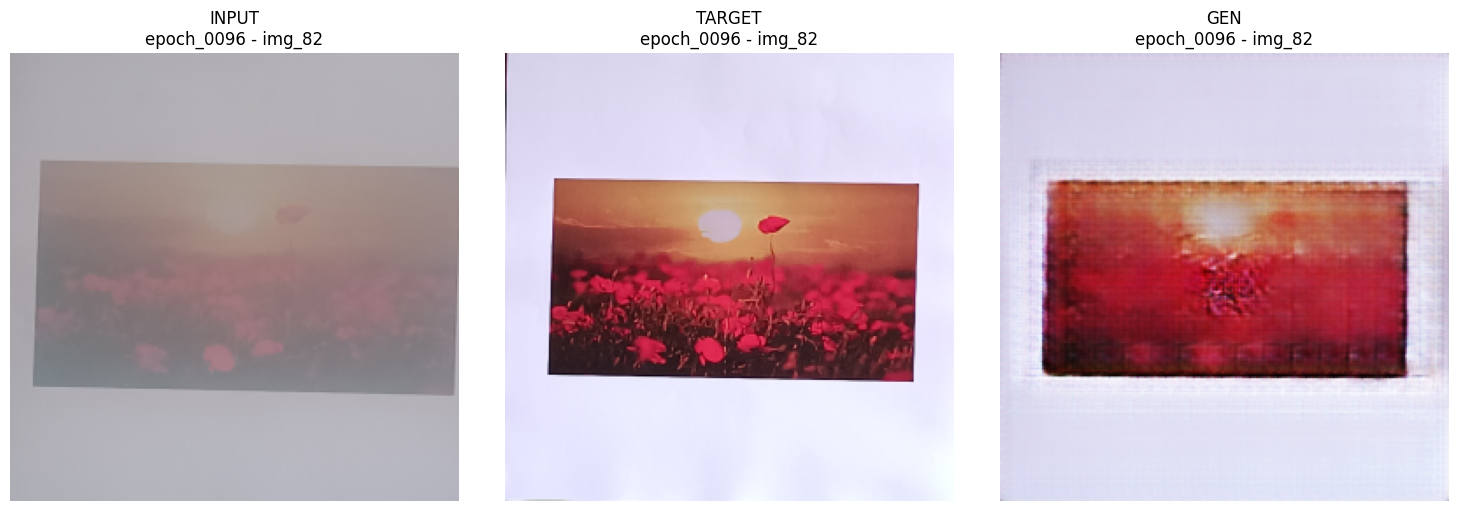

In [33]:
for _, row in sample.iterrows():

    archive = row["source_archive"]
    image_id = row["image_id"]

    sample_images = df[

        (df["source_archive"] == archive) &

        (df["image_id"] == image_id)

    ]


    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    categories = [
        "input",
        "target",
        "gen"
    ]


    for ax, category in zip(
        axes,
        categories
    ):

        file_path = sample_images[

            sample_images["category"] == category

        ]["file"].iloc[0]


        image = Image.open(file_path)

        ax.imshow(image)

        ax.set_title(
            f"{category.upper()}\n"
            f"{archive} - img_{image_id}"
        )

        ax.axis("off")


    plt.tight_layout()

    plt.show()

In [34]:
summary = {

    "Total image files":
        len(image_files),

    "Input images":
        (df["category"] == "input").sum(),

    "Target images":
        (df["category"] == "target").sum(),

    "Generated images":
        (df["category"] == "gen").sum(),

    "Valid images":
        len(valid_images),

    "Corrupt images":
        len(corrupt_images),

    "Total samples":
        len(triplet_df),

    "Complete triplets":
        triplet_df[
            "complete_triplet"
        ].sum(),

    "Incomplete triplets":
        (
            ~triplet_df[
                "complete_triplet"
            ]
        ).sum(),

    "Resolution inconsistencies":
        len(resolution_problems_df),

    "Files involved in duplicates":
        len(duplicates_df),

    "Potentially dark images":
        len(dark_images),

    "Potentially blurry images":
        len(blurry_images)

}


summary_df = pd.DataFrame(

    summary.items(),

    columns=[
        "Metric",
        "Value"
    ]

)

summary_df

,Metric,Value
0,Total image files,3694
1,Input images,157
2,Target images,157
3,Generated images,157
4,Valid images,3694
5,Corrupt images,0
6,Total samples,157
7,Complete triplets,157
8,Incomplete triplets,0
9,Resolution inconsistencies,0


In [35]:
summary_df.to_csv(
    "/content/dataset_quality_summary.csv",
    index=False
)